# Data Visualisation
**Decodelabs Internship | Week 2 | Task 4**

---


In [1]:
import sys, os
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from configs.config import (
    RAW_FILE, IDS_MAP_FILE, INTERIM_FILE, PROCESSED_FILE,
    TRAIN_FILE, VAL_FILE, TEST_FILE,
    FIGURES_DIR, TABLES_DIR, PAPER_FIG_DIR, PAPER_TAB_DIR,
    RANDOM_SEED, TARGET_COL, PATIENT_ID_COL, MEDICATION_COLS,
    AGE_ORDER, icd9_to_category, COLORS, ensure_dirs
)
from src.plot_utils import set_plot_style, save_figure, save_table
ensure_dirs()
set_plot_style()
print("Config loaded. Seed:", RANDOM_SEED)


Config loaded. Seed: 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_curve, precision_recall_curve,
                              roc_auc_score, average_precision_score,
                              confusion_matrix)
import warnings
warnings.filterwarnings("ignore")

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False

# Load datasets
df       = pd.read_csv(PROCESSED_FILE)
train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train  = train_df.drop(columns=[TARGET_COL])
y_train  = train_df[TARGET_COL]
X_val    = val_df.drop(columns=[TARGET_COL])
y_val    = val_df[TARGET_COL]
X_test   = test_df.drop(columns=[TARGET_COL])
y_test   = test_df[TARGET_COL]

X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

print(f"Processed data : {df.shape[0]:,} rows")
print(f"Test set       : {len(X_test):,} rows | {y_test.mean()*100:.1f}% positive")


Processed data : 69,987 rows
Test set       : 10,499 rows | 7.2% positive


## Dataset overview dashboard

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\10_dataset_overview_dashboard.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\10_dataset_overview_dashboard.png


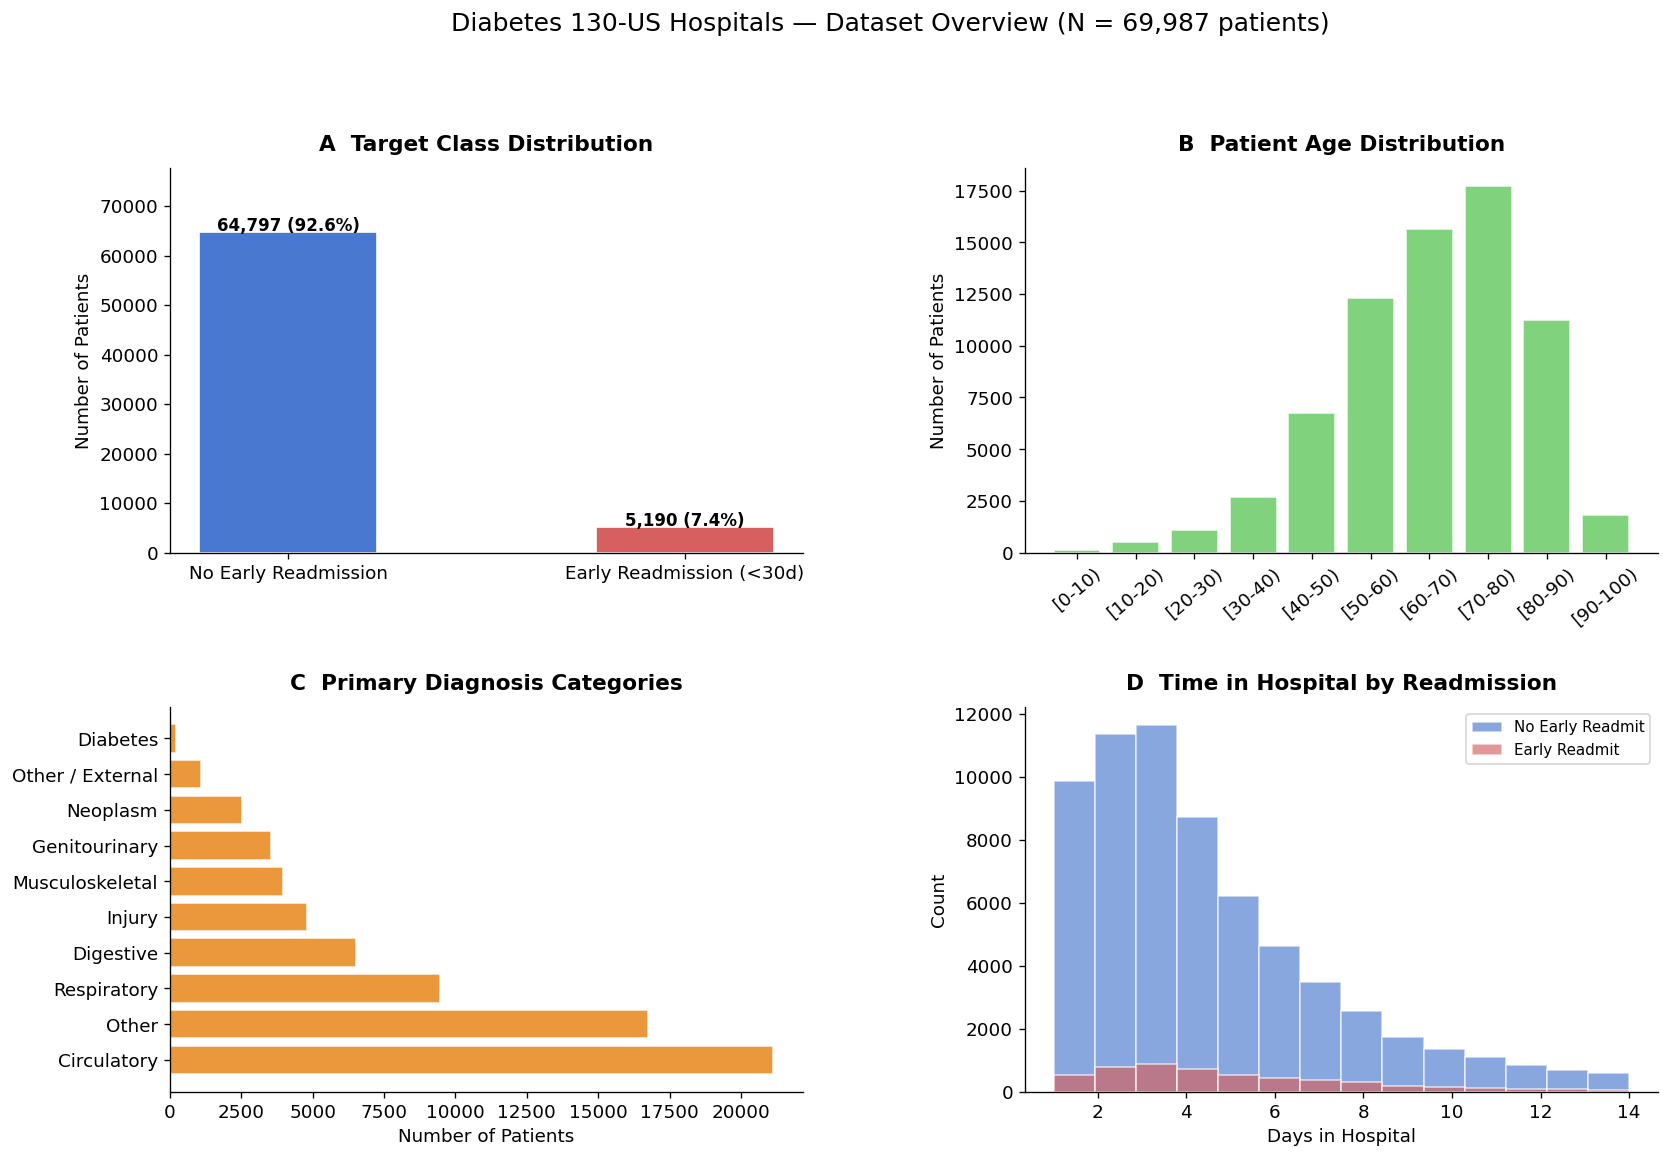

Figure 1 saved.


In [ ]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel A: Class balance ─────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
counts  = df[TARGET_COL].value_counts().sort_index()
bars    = ax_a.bar(["No Early Readmission", "Early Readmission (<30d)"], counts.values, color=[COLORS["no_readmit"], COLORS["readmit"]], width=0.45, edgecolor="white")

for bar, cnt in zip(bars, counts.values):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, f"{cnt:,} ({cnt/len(df)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax_a.set_title("A  Target Class Distribution", fontweight="bold", pad=10)
ax_a.set_ylabel("Number of Patients")
ax_a.set_ylim(0, max(counts.values) * 1.2)

# ── Panel B: Age distribution ──────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
age_order = sorted(AGE_ORDER.items(), key=lambda x: x[1])
age_labels = [k for k, v in age_order]
age_vals   = df["age_ordinal"].value_counts().sort_index()
age_bar_vals = [age_vals.get(v, 0) for _, v in age_order]

bars_b = ax_b.bar(age_labels, age_bar_vals, color=COLORS["neutral"], alpha=0.85, edgecolor="white")
ax_b.set_title("B  Patient Age Distribution", fontweight="bold", pad=10)
ax_b.set_ylabel("Number of Patients")
ax_b.tick_params(axis="x", rotation=40)

# ── Panel C: Diagnosis categories ─────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
if "diag_1_cat" in df.columns:
    diag_vc = df["diag_1_cat"].value_counts()
    ax_c.barh(diag_vc.index, diag_vc.values, color=COLORS["highlight"], alpha=0.85, edgecolor="white")
    ax_c.set_title("C  Primary Diagnosis Categories", fontweight="bold", pad=10)
    ax_c.set_xlabel("Number of Patients")

# ── Panel D: Time in hospital ──────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d.hist(df[df[TARGET_COL]==0]["time_in_hospital"], bins=14, alpha=0.65, color=COLORS["no_readmit"], label="No Early Readmit", edgecolor="white")
ax_d.hist(df[df[TARGET_COL]==1]["time_in_hospital"], bins=14, alpha=0.65, color=COLORS["readmit"], label="Early Readmit", edgecolor="white")
ax_d.set_title("D  Time in Hospital by Readmission", fontweight="bold", pad=10)
ax_d.set_xlabel("Days in Hospital")
ax_d.set_ylabel("Count")
ax_d.legend(fontsize=9)

fig.suptitle("Diabetes 130-US Hospitals — Dataset Overview (N = {:,} patients)".format(len(df)), fontsize=15, y=1.01)

save_figure(fig, "10_dataset_overview_dashboard.png", FIGURES_DIR, dpi=180)
save_figure(fig, "10_dataset_overview_dashboard.png", PAPER_FIG_DIR, dpi=180)
plt.show()
print("Figure 1 saved.")

## Feature readmission rate comparison (top features)

A horizontal bar chart comparing the readmission rate for key features. Shows which categorical/binary features are associated with higher risk.

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\10_feature_readmission_rates.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\10_feature_readmission_rates.png


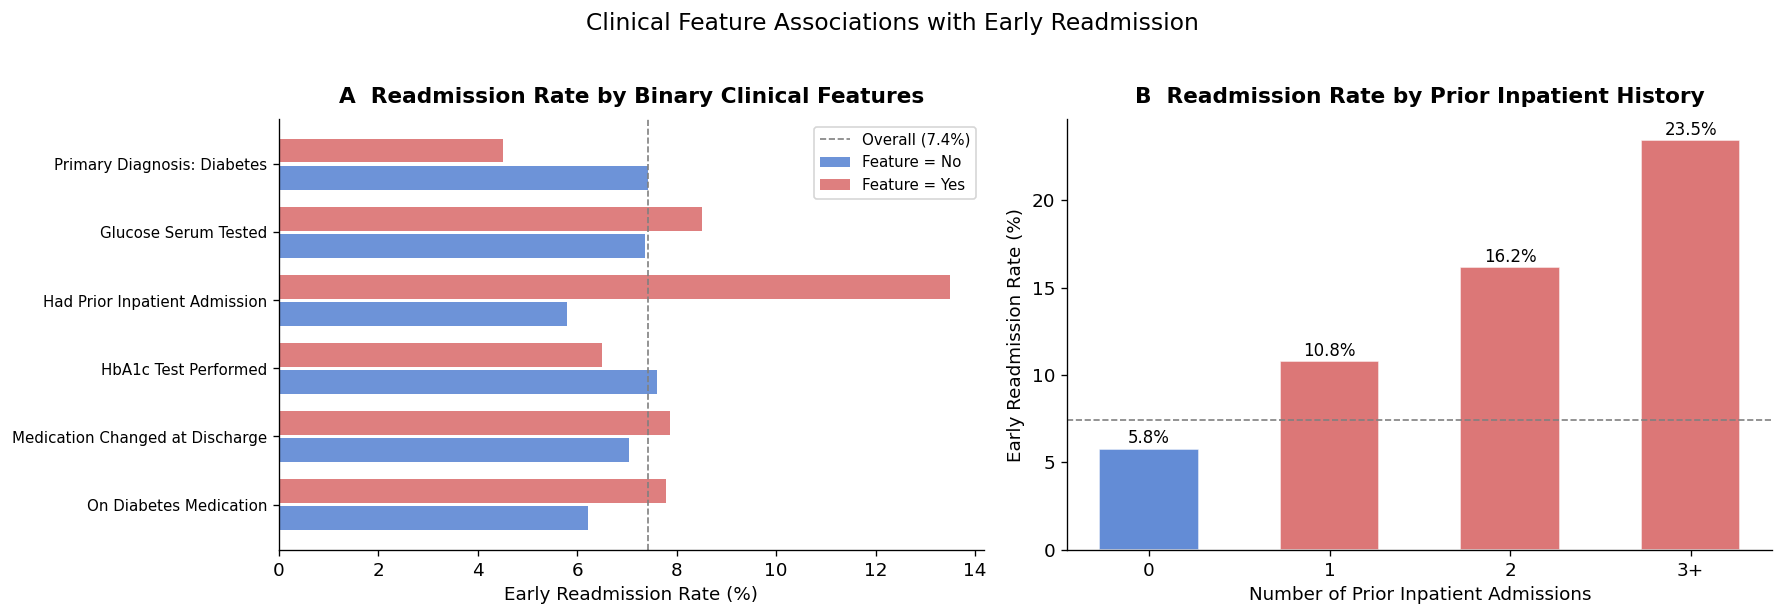

In [ ]:
binary_cat_features = [
    ("on_diabetes_med",       "On Diabetes Medication"),
    ("med_changed",           "Medication Changed at Discharge"),
    ("A1C_tested",            "HbA1c Test Performed"),
    ("had_prior_inpatient",   "Had Prior Inpatient Admission"),
    ("glucose_tested",        "Glucose Serum Tested"),
    ("primary_diag_is_diabetes", "Primary Diagnosis: Diabetes"),
]

binary_cat_features = [(c, l) for c, l in binary_cat_features if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: readmission rate for binary features
ax = axes[0]
feature_rates = []
for col, label in binary_cat_features:
    rate_0 = df[df[col]==0][TARGET_COL].mean() * 100
    rate_1 = df[df[col]==1][TARGET_COL].mean() * 100
    feature_rates.append((label, rate_0, rate_1))

labels   = [r[0] for r in feature_rates]
rates_no = [r[1] for r in feature_rates]
rates_yes = [r[2] for r in feature_rates]
y_pos    = np.arange(len(labels))

ax.barh(y_pos - 0.2, rates_no,  height=0.35, color=COLORS["no_readmit"],
        alpha=0.8, label="Feature = No")
ax.barh(y_pos + 0.2, rates_yes, height=0.35, color=COLORS["readmit"],
        alpha=0.8, label="Feature = Yes")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(df[TARGET_COL].mean()*100, color="gray", linestyle="--",
           label=f"Overall ({df[TARGET_COL].mean()*100:.1f}%)", linewidth=1)
ax.set_xlabel("Early Readmission Rate (%)")
ax.set_title("A  Readmission Rate by Binary Clinical Features",
             fontweight="bold", pad=10)
ax.legend(fontsize=9)

# Right: readmission rate by number of prior inpatient visits (0,1,2,3+)
ax2 = axes[1]
df_temp = df.copy()
df_temp["inpatient_group"] = df_temp["number_inpatient"].clip(upper=3)
df_temp["inpatient_group"] = df_temp["inpatient_group"].map(
    {0:"0",1:"1",2:"2",3:"3+"})
inpt_rate = df_temp.groupby("inpatient_group")[TARGET_COL].mean() * 100

bar_colors = [COLORS["no_readmit"] if r < df[TARGET_COL].mean()*100
              else COLORS["readmit"] for r in inpt_rate.values]
ax2.bar(inpt_rate.index, inpt_rate.values, color=bar_colors,
        alpha=0.85, edgecolor="white", width=0.55)
for i, (grp, rate) in enumerate(inpt_rate.items()):
    ax2.text(i, rate + 0.3, f"{rate:.1f}%", ha="center", fontsize=10)
ax2.axhline(df[TARGET_COL].mean()*100, color="gray", linestyle="--", linewidth=1)
ax2.set_xlabel("Number of Prior Inpatient Admissions")
ax2.set_ylabel("Early Readmission Rate (%)")
ax2.set_title("B  Readmission Rate by Prior Inpatient History",
              fontweight="bold", pad=10)

fig.suptitle("Clinical Feature Associations with Early Readmission",
             fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "10_feature_readmission_rates.png", FIGURES_DIR, dpi=180)
save_figure(fig, "10_feature_readmission_rates.png", PAPER_FIG_DIR, dpi=180)
plt.show()

## Model performance comparison

In [6]:
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
    X_tv_res, y_tv_res = smote.fit_resample(X_tv, y_tv)
else:
    X_tv_res, y_tv_res = X_tv, y_tv

fit_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000,
                                               random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10,
                                            min_samples_leaf=20, class_weight="balanced_subsample",
                                            random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, subsample=0.8,
                                                     random_state=RANDOM_SEED),
}

try:
    from xgboost import XGBClassifier
    sw = (y_tv_res==0).sum()/(y_tv_res==1).sum()
    fit_models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, subsample=0.8,
                                          scale_pos_weight=sw, eval_metric="auc",
                                          random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
except ImportError:
    pass

print("Training models for visualisation...")
for name, model in fit_models.items():
    model.fit(X_tv_res, y_tv_res)
    print(f"  ✓ {name}")

model_probs_test = {name: model.predict_proba(X_test)[:,1]
                    for name, model in fit_models.items()}

Training models for visualisation...
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ XGBoost


  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\10_model_performance_comparison.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\10_model_performance_comparison.png


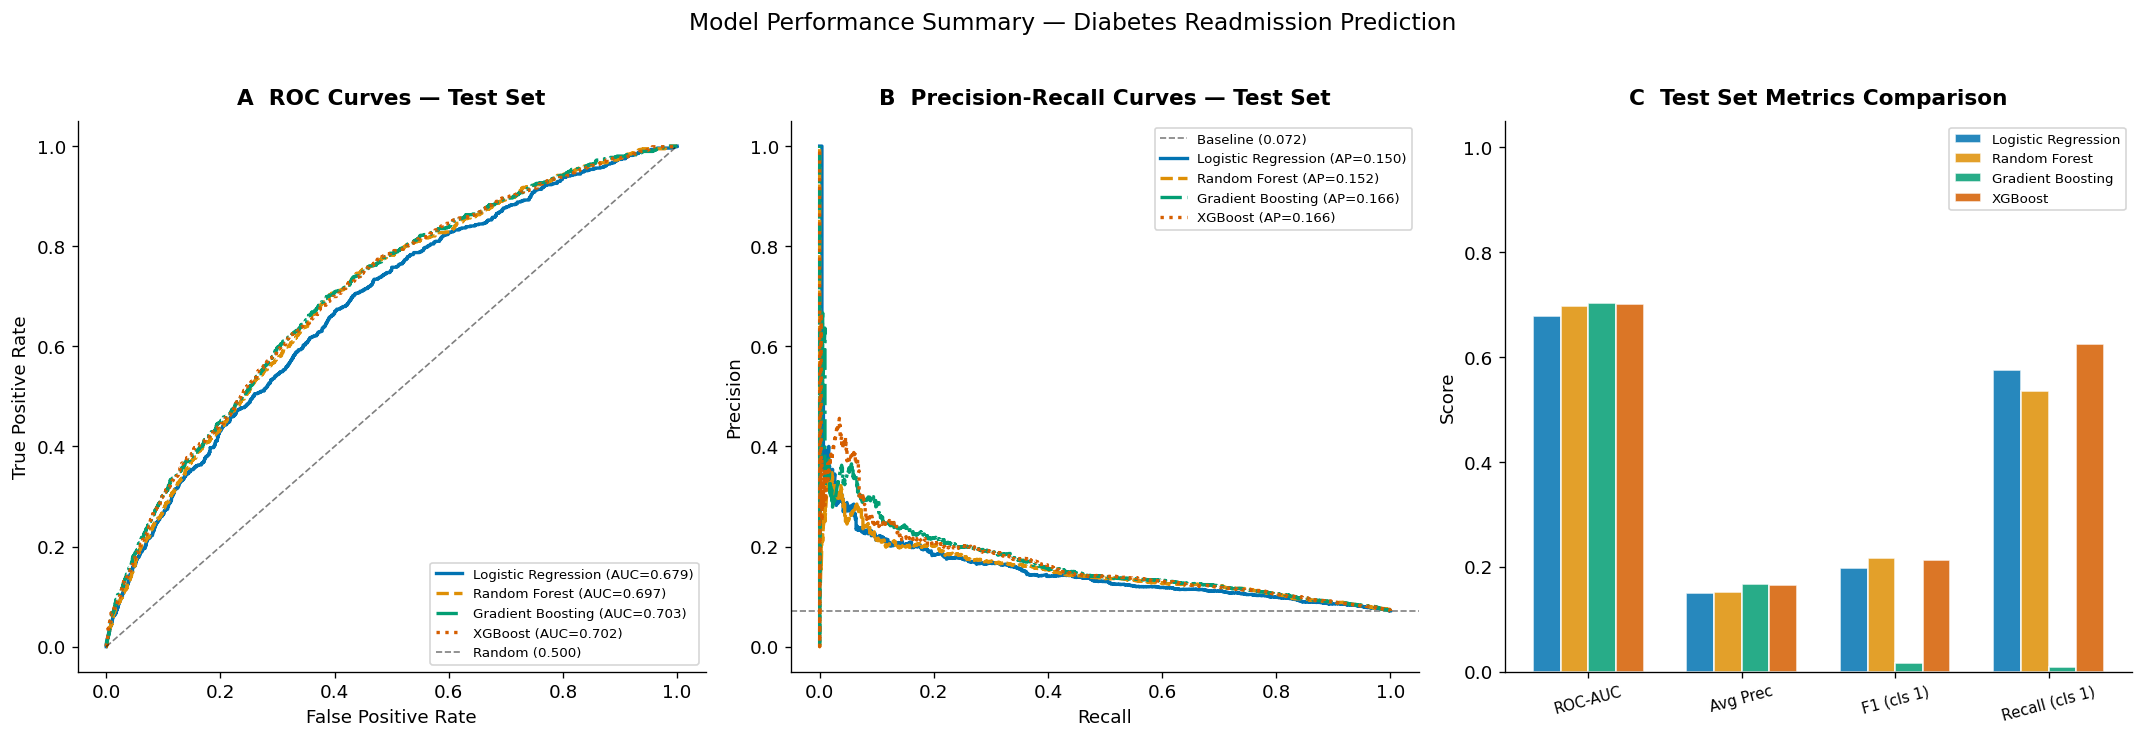

Figure 3 saved.


In [7]:
# Multi-panel: ROC + PR + metric bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── ROC curves ─────────────────────────────────────────────────────────────
ax = axes[0]
palette = sns.color_palette("colorblind", len(model_probs_test))
ls_list = ["-", "--", "-.", ":"]
for (name, y_prob), color, ls in zip(model_probs_test.items(), palette, ls_list):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, ls=ls, lw=2)
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random (0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("A  ROC Curves — Test Set", fontweight="bold", pad=10)
ax.legend(fontsize=8, loc="lower right")

# ── PR curves ──────────────────────────────────────────────────────────────
ax2 = axes[1]
baseline_pr = y_test.mean()
ax2.axhline(baseline_pr, color="gray", ls="--", lw=1,
            label=f"Baseline ({baseline_pr:.3f})")
for (name, y_prob), color, ls in zip(model_probs_test.items(), palette, ls_list):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax2.plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, ls=ls, lw=2)
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("B  Precision-Recall Curves — Test Set", fontweight="bold", pad=10)
ax2.legend(fontsize=8, loc="upper right")

# ── Metric bar chart ───────────────────────────────────────────────────────
ax3 = axes[2]
from sklearn.metrics import f1_score, recall_score
metric_names = ["ROC-AUC", "Avg Prec", "F1 (cls 1)", "Recall (cls 1)"]
model_names  = list(fit_models.keys())
metric_vals  = []

for name, model in fit_models.items():
    y_pred = model.predict(X_test)
    y_prob = model_probs_test[name]
    metric_vals.append([
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob),
        f1_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
    ])

x_pos   = np.arange(len(metric_names))
bar_w   = 0.18
offsets = np.linspace(-(len(model_names)-1)/2 * bar_w,
                       (len(model_names)-1)/2 * bar_w, len(model_names))

for idx, (name, vals, color) in enumerate(zip(model_names, metric_vals, palette)):
    ax3.bar(x_pos + offsets[idx], vals, width=bar_w, color=color,
            alpha=0.85, label=name, edgecolor="white")

ax3.set_xticks(x_pos)
ax3.set_xticklabels(metric_names, rotation=15, fontsize=9)
ax3.set_ylim(0, 1.05)
ax3.set_ylabel("Score")
ax3.set_title("C  Test Set Metrics Comparison", fontweight="bold", pad=10)
ax3.legend(fontsize=8)

fig.suptitle("Model Performance Summary — Diabetes Readmission Prediction",
             fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "10_model_performance_comparison.png", FIGURES_DIR, dpi=180)
save_figure(fig, "10_model_performance_comparison.png", PAPER_FIG_DIR, dpi=180)
plt.show()
print("Figure 3 saved.")

## EDA: who gets readmitted?

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\10_eda_storytelling_dashboard.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\10_eda_storytelling_dashboard.png


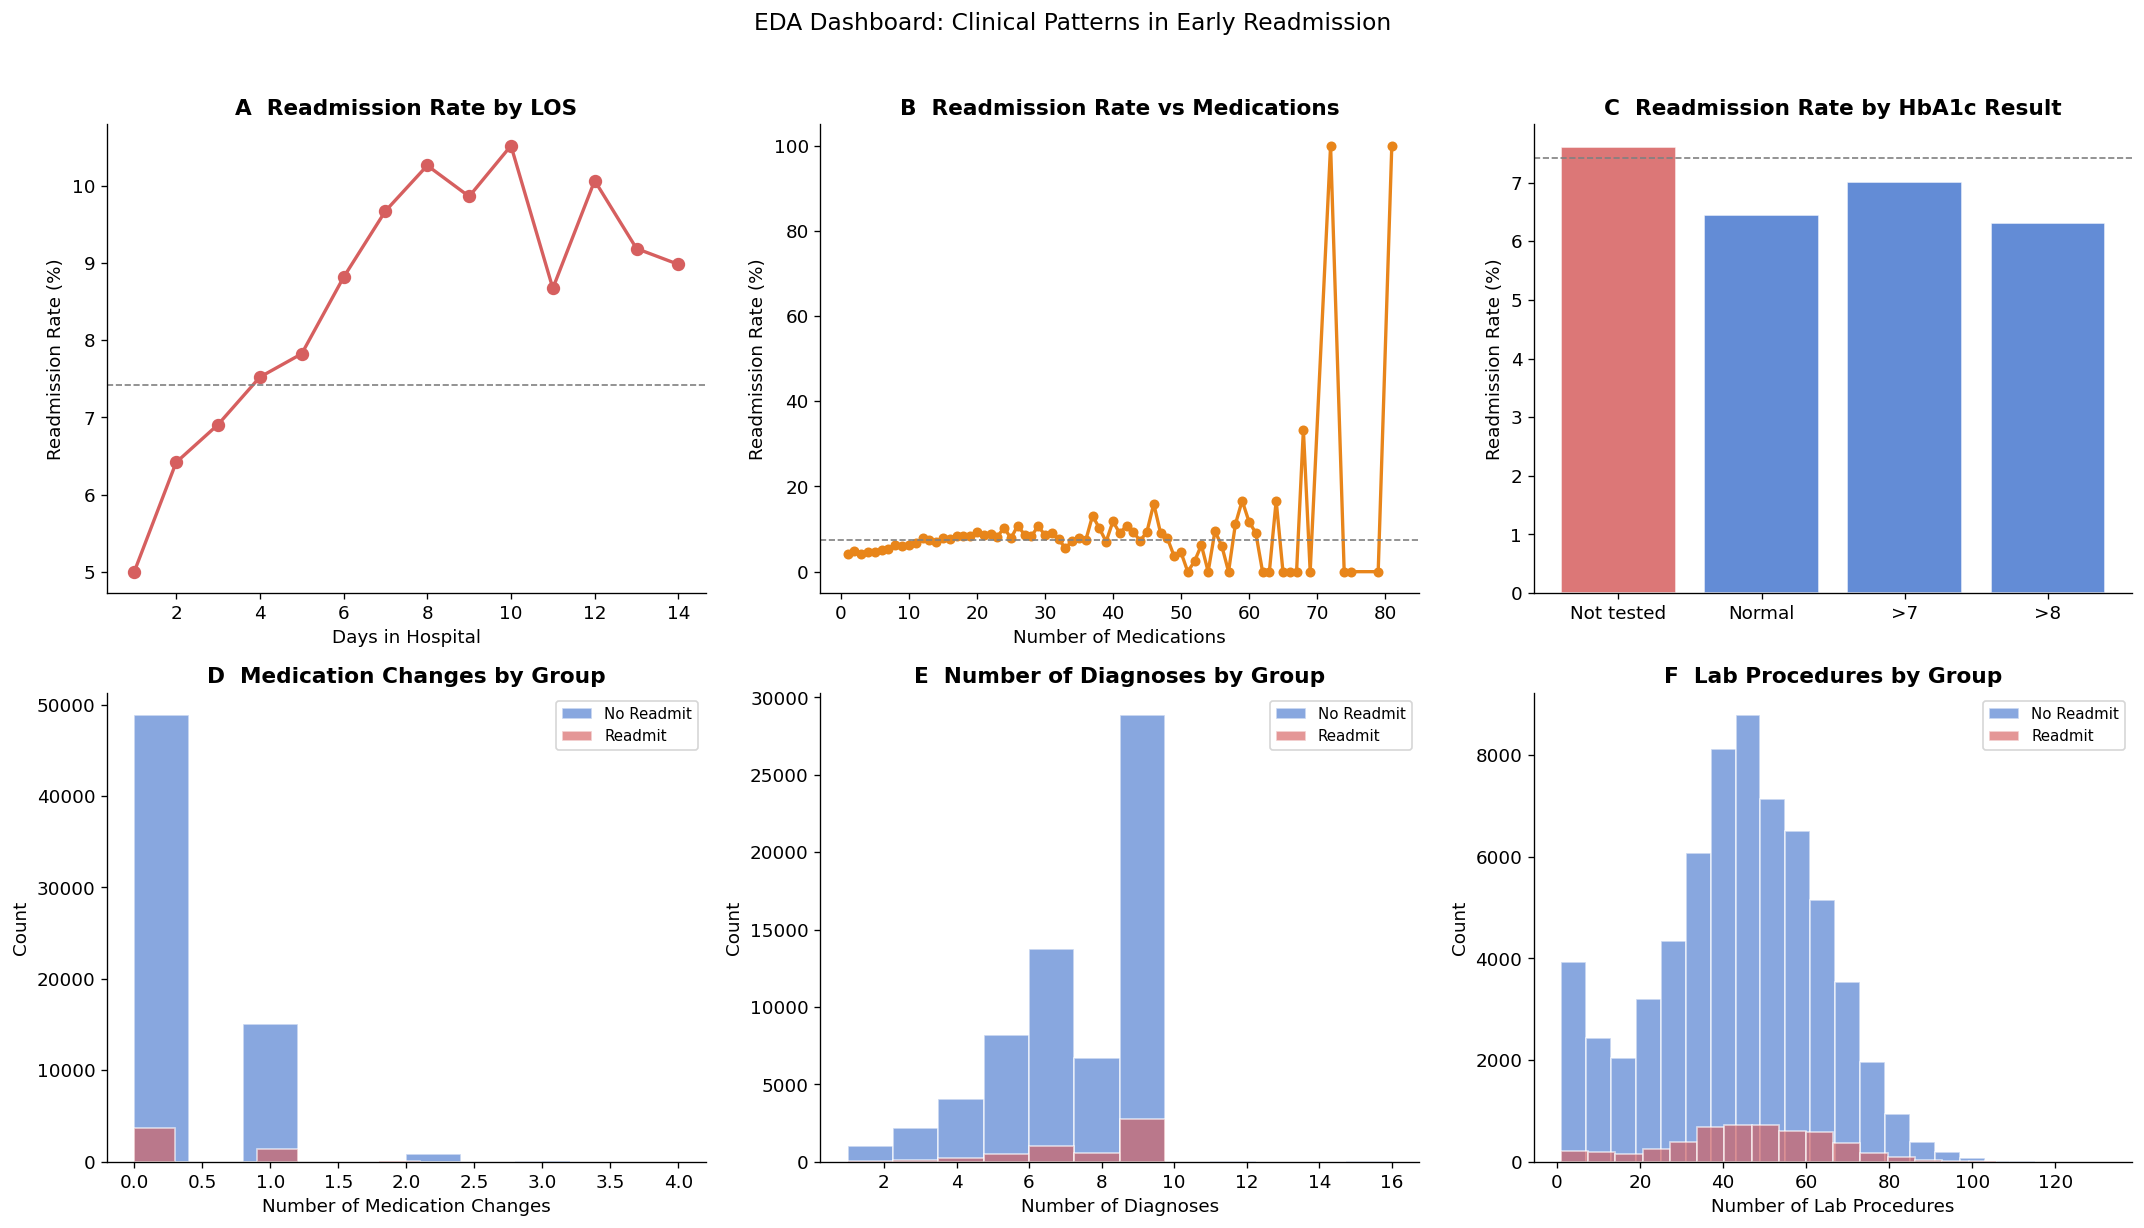

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Panel 1: Readmission rate by time in hospital ──────────────────────────
ax = axes[0, 0]
df_g = df.groupby("time_in_hospital")[TARGET_COL].mean() * 100
ax.plot(df_g.index, df_g.values, "o-", color=COLORS["readmit"], lw=2, ms=7)
ax.axhline(df[TARGET_COL].mean()*100, color="gray", ls="--", lw=1)
ax.set_xlabel("Days in Hospital"); ax.set_ylabel("Readmission Rate (%)")
ax.set_title("A  Readmission Rate by LOS", fontweight="bold")

# ── Panel 2: Readmission rate by number of medications ────────────────────
ax = axes[0, 1]
df_g2 = df.groupby("num_medications")[TARGET_COL].mean() * 100
ax.plot(df_g2.index, df_g2.values, "o-", color=COLORS["highlight"], lw=2, ms=5)
ax.axhline(df[TARGET_COL].mean()*100, color="gray", ls="--", lw=1)
ax.set_xlabel("Number of Medications"); ax.set_ylabel("Readmission Rate (%)")
ax.set_title("B  Readmission Rate vs Medications", fontweight="bold")

# ── Panel 3: Readmission by A1C result ────────────────────────────────────
ax = axes[0, 2]
if "A1Cresult_encoded" in df.columns:
    a1c_map_rev = {0:"Not tested",1:"Normal",2:">7",3:">8"}
    a1c_rate = df.groupby("A1Cresult_encoded")[TARGET_COL].mean() * 100
    a1c_labels = [a1c_map_rev.get(int(k), str(k)) for k in a1c_rate.index]
    bar_colors = [COLORS["no_readmit"] if r < df[TARGET_COL].mean()*100
                  else COLORS["readmit"] for r in a1c_rate.values]
    ax.bar(a1c_labels, a1c_rate.values, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.axhline(df[TARGET_COL].mean()*100, color="gray", ls="--", lw=1)
    ax.set_ylabel("Readmission Rate (%)")
    ax.set_title("C  Readmission Rate by HbA1c Result", fontweight="bold")

# ── Panel 4: Medication changes histogram by group ─────────────────────────
ax = axes[1, 0]
if "n_medication_changes" in df.columns:
    ax.hist(df[df[TARGET_COL]==0]["n_medication_changes"], bins=10,
            alpha=0.65, color=COLORS["no_readmit"], label="No Readmit", edgecolor="white")
    ax.hist(df[df[TARGET_COL]==1]["n_medication_changes"], bins=10,
            alpha=0.65, color=COLORS["readmit"],    label="Readmit", edgecolor="white")
    ax.set_xlabel("Number of Medication Changes"); ax.set_ylabel("Count")
    ax.set_title("D  Medication Changes by Group", fontweight="bold")
    ax.legend(fontsize=9)

# ── Panel 5: Number of diagnoses distribution ─────────────────────────────
ax = axes[1, 1]
ax.hist(df[df[TARGET_COL]==0]["number_diagnoses"], bins=12,
        alpha=0.65, color=COLORS["no_readmit"], label="No Readmit", edgecolor="white")
ax.hist(df[df[TARGET_COL]==1]["number_diagnoses"], bins=12,
        alpha=0.65, color=COLORS["readmit"],    label="Readmit", edgecolor="white")
ax.set_xlabel("Number of Diagnoses"); ax.set_ylabel("Count")
ax.set_title("E  Number of Diagnoses by Group", fontweight="bold")
ax.legend(fontsize=9)

# ── Panel 6: Lab procedures vs readmission ─────────────────────────────────
ax = axes[1, 2]
ax.hist(df[df[TARGET_COL]==0]["num_lab_procedures"], bins=20,
        alpha=0.65, color=COLORS["no_readmit"], label="No Readmit", edgecolor="white")
ax.hist(df[df[TARGET_COL]==1]["num_lab_procedures"], bins=20,
        alpha=0.65, color=COLORS["readmit"],    label="Readmit", edgecolor="white")
ax.set_xlabel("Number of Lab Procedures"); ax.set_ylabel("Count")
ax.set_title("F  Lab Procedures by Group", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("EDA Dashboard: Clinical Patterns in Early Readmission",
             fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "10_eda_storytelling_dashboard.png", FIGURES_DIR, dpi=180)
save_figure(fig, "10_eda_storytelling_dashboard.png", PAPER_FIG_DIR, dpi=180)
plt.show()

## Correlation heatmap

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\10_correlation_heatmap.png
  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\paper_or_report\figures\10_correlation_heatmap.png


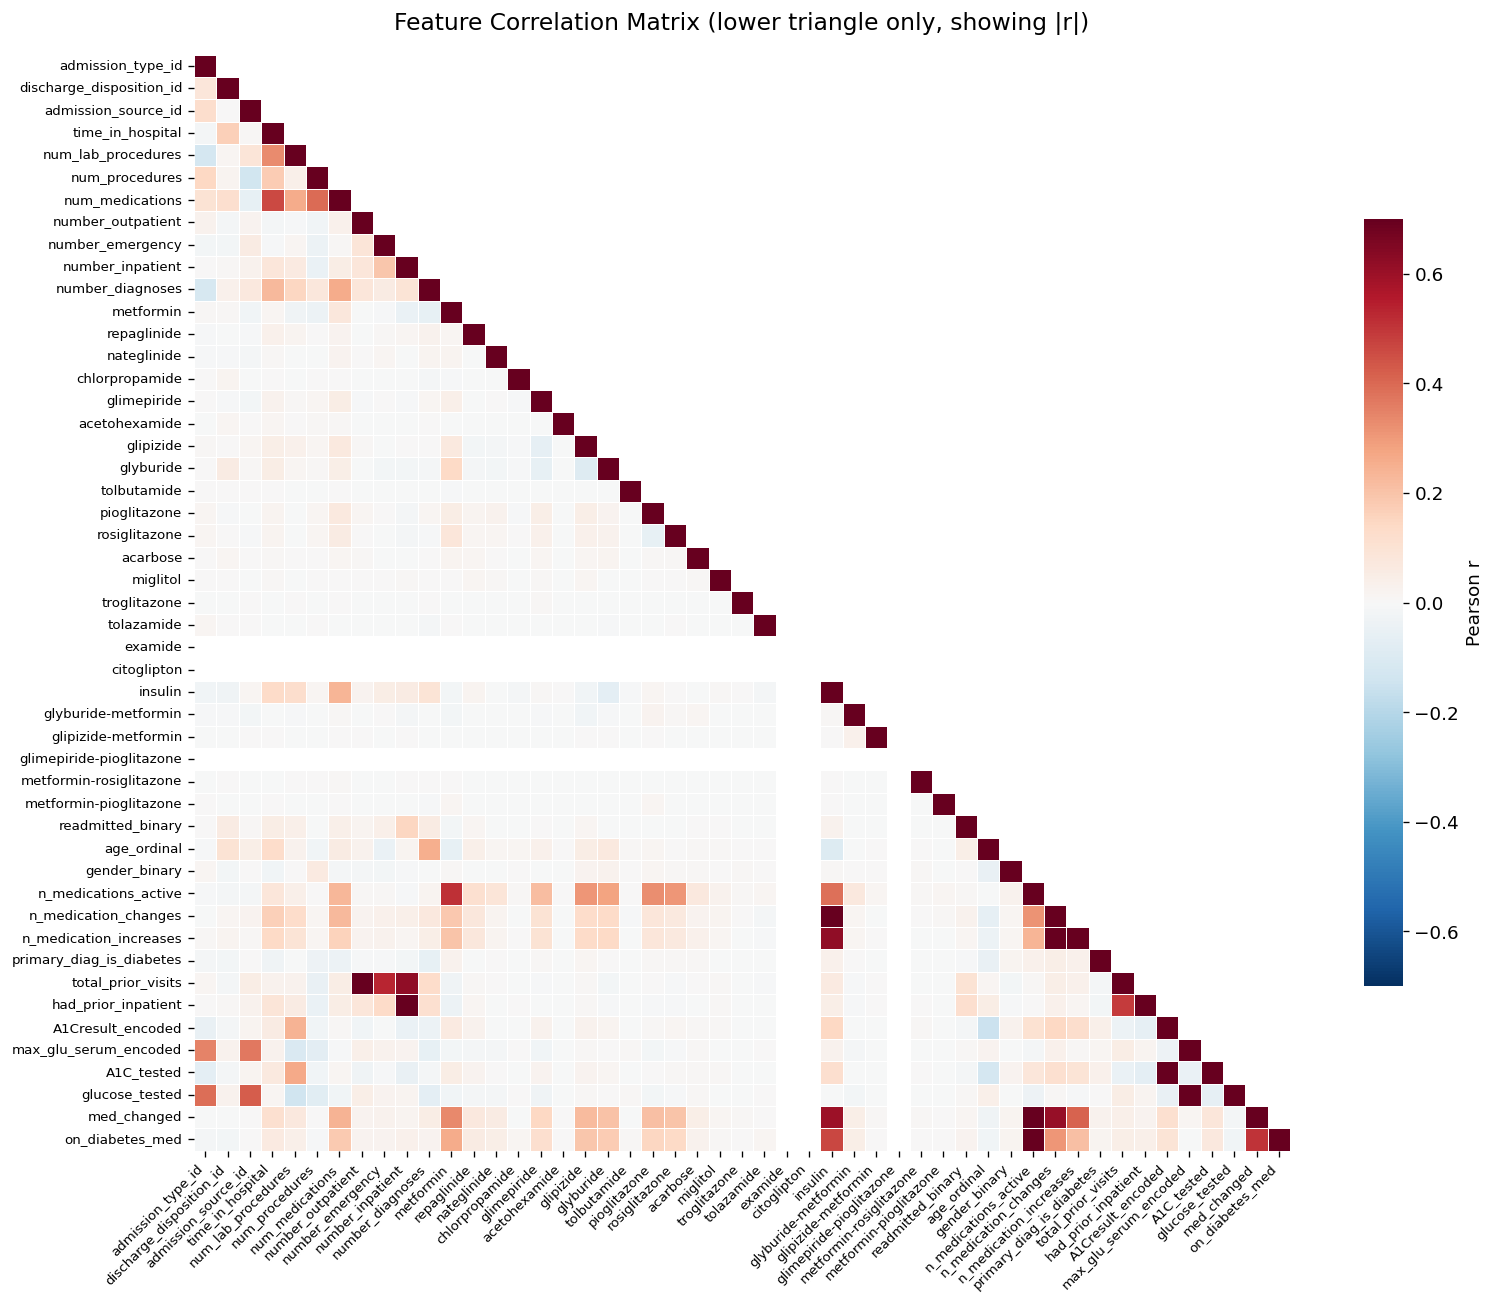

In [9]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in [PATIENT_ID_COL]]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # hide upper triangle

sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r",
            center=0, vmin=-0.7, vmax=0.7, square=True,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7, "label": "Pearson r"})
ax.set_title("Feature Correlation Matrix (lower triangle only, showing |r|)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
save_figure(fig, "10_correlation_heatmap.png", FIGURES_DIR, dpi=180)
save_figure(fig, "10_correlation_heatmap.png", PAPER_FIG_DIR, dpi=180)
plt.show()

## All visualisation figures saved

In [10]:
all_figs = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith(".png")])
print(f"Total figures in reports/figures/ : {len(all_figs)}")
for fig_name in all_figs:
    print(f"  {fig_name}")

Total figures in reports/figures/ : 16
  01_age_distribution.png
  04_class_balance.png
  04_clinical_distributions.png
  04_diagnosis_categories.png
  04_medication_distributions.png
  05_boxplots_by_target.png
  05_correlation_heatmap.png
  05_readmission_by_age.png
  05_target_correlations.png
  09_confusion_matrices.png
  09_roc_and_pr_curves.png
  10_correlation_heatmap.png
  10_dataset_overview_dashboard.png
  10_eda_storytelling_dashboard.png
  10_feature_readmission_rates.png
  10_model_performance_comparison.png
